In [29]:
import tensorflow as tf
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from ultralytics import YOLO
from PIL import Image
import cv2
import torch
from ultralytics import YOLO
import matplotlib.patches as patches

In [20]:
# Load the SavedModel
model = tf.saved_model.load("models/yolo11n_tf")
infer = model.signatures["serving_default"]

In [50]:
def preprocess_image(path, size=(640, 640)):
    image = Image.open(path).convert("RGB").resize(size)
    img_np = np.array(image, dtype=np.float32) / 255.0
    img_np = img_np.transpose(2, 0, 1)  # HWC → CHW
    img_tensor = tf.convert_to_tensor(img_np[np.newaxis, ...])  # Add batch
    return img_tensor, image

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def draw_detections(image, boxes, scores):
    fig, ax = plt.subplots(1)
    ax.imshow(image)
    for box, score in zip(boxes, scores):
        x, y, w, h = map(int, box)
        label_text = f"{score:.2f}"
        rect = patches.Rectangle((x, y), w, h, linewidth=1, linestyle='dashed', edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        # Draw label text just above the top-right corner of the box
        ax.text(x + w, y - 5, label_text, color='green', fontsize=10, va='bottom', ha='right', bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))
    
    plt.axis('off')
    plt.show()
    plt.close()
    return 0

In [57]:
def postprocess(preds, image_size=(640, 640), conf_thresh=0.3, iou_thresh=0.7):
    preds = preds[0].numpy()  # shape: (84, 8400)
    preds = preds.transpose(1, 0)  # (8400, 84)

    boxes = preds[:, :4]                         # (cx, cy, w, h)
    objectness = sigmoid(preds[:, 4])
    person_scores = sigmoid(preds[:, 5])         # Only class 0 ("person")

    conf = objectness * person_scores
    mask = conf > conf_thresh
    boxes, conf = boxes[mask], conf[mask]

    if len(boxes) == 0:
        return np.empty((0, 4)), np.empty((0,)), np.empty((0,), dtype=int)

    # Convert boxes: cx, cy, w, h → x1, y1, x2, y2
    cx, cy, w, h = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
    x1 = cx - w / 2
    y1 = cy - h / 2
    # x2 = cx + w / 2
    # y2 = cy + h / 2
    boxes_xywh = np.stack([x1, y1, w, h], axis=1)

    # NMS
    selected = tf.image.non_max_suppression(
        boxes=boxes_xywh,
        scores=conf,
        max_output_size=50,
        iou_threshold=iou_thresh,
        score_threshold=conf_thresh
    )

    selected_boxes = boxes_xywh[selected]
    selected_scores = conf[selected]
    selected_classes = np.zeros_like(selected_scores, dtype=int)  # class 0 for person

    return selected_boxes, selected_scores, selected_classes


In [41]:
# Load a COCO-pretrained YOLOv8n model
yolo_model = YOLO("models/yolo11n.pt")

def get_bboxes(image,  person_class = 0):
    results = yolo_model(image)
    idxes = torch.where(results[0].boxes.cls == person_class)
    bboxes = results[0].boxes.xywh[idxes]
    conf = results[0].boxes.conf[idxes]
    return bboxes, conf
    

In [48]:
def compare_model(image_path):
    
    input_tensor, pil_image = preprocess_image(image_path)
    output = infer(images=input_tensor)["output0"]
    boxes, scores, classes = postprocess(output)
    draw_detections(pil_image, boxes, scores)
    boxes, score = get_bboxes(image_path)
    draw_detections(pil_image, boxes, scores)


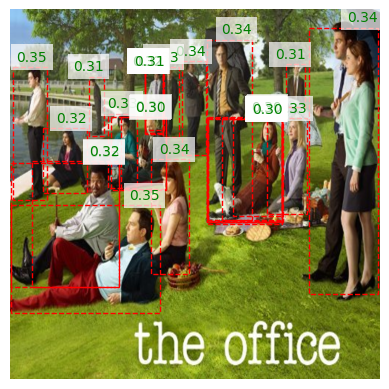


image 1/1 e:\synclabs\edgeface\group_test\office5.jpg: 480x640 19 persons, 3 umbrellas, 1 frisbee, 1 bottle, 13.0ms
Speed: 1.8ms preprocess, 13.0ms inference, 2.5ms postprocess per image at shape (1, 3, 480, 640)


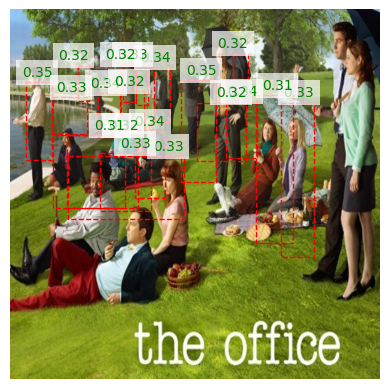

In [51]:
compare_model(image_path = "group_test/office5.jpg")

In [ ]:
# import tensorflow as tf
# tf.get_logger().setLevel('DEBUG')
# # Path to the SavedModel directory
# saved_model_dir = 'models/edgeface_tf'

# # Convert the SavedModel to TensorFlow Lite format
# converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
# converter.allow_custom_ops = True 
# tflite_model = converter.convert()

# # Save the TFLite model to a file
# with open('models/edgeface.tflite', 'wb') as f:
#     f.write(tflite_model)


In [65]:
import tensorflow as tf

# Example of modifying the model to replace 'Erf' with an alternative
# Assuming model is already loaded as `model`
model = tf.keras.models.load_model('models/edgeface_tf')

# Replace Erf with a different operation
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Lambda):
        if 'Erf' in str(layer.function):
            layer.function = tf.square  # Replace with a compatible function

# Save the modified model
model.save('models/modified_edgeface.h5')

ValueError: File format not supported: filepath=models/edgeface_tf. Keras 3 only supports V3 `.keras` files and legacy H5 format files (`.h5` extension). Note that the legacy SavedModel format is not supported by `load_model()` in Keras 3. In order to reload a TensorFlow SavedModel as an inference-only layer in Keras 3, use `keras.layers.TFSMLayer(models/edgeface_tf, call_endpoint='serving_default')` (note that your `call_endpoint` might have a different name).

In [69]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TFSMLayer
# Create a model using TFSMLayer to load the SavedModel
model = Sequential([
    TFSMLayer('models/edgeface_tf', call_endpoint='serving_default')  # Ensure 'serving_default' is correct
])

# Now the model is ready for inference


In [71]:
import numpy as np

# Example input data (replace with your actual input)
input_data = np.random.random((1, 224, 224, 3))  # Adjust the shape to match the model's expected input

# Perform inference
model(input_data)




ValueError: Layers added to a Sequential model can only have a single positional argument, the input tensor. Layer TFSMLayer has multiple positional arguments: [<Parameter "inputs">, <Parameter "**kwargs">]

In [73]:
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, TFSMLayer
input_tensor = Input(shape=(224, 224, 3))  # Example shape, change if necessary

# Use TFSMLayer to load the SavedModel for inference
tfsmlayer = TFSMLayer('models/edgeface_tf', call_endpoint='serving_default')

# Create the custom model
model = Model(inputs=input_tensor, outputs=tfsmlayer(input_tensor))

TypeError: Exception encountered when calling TFSMLayer.call().

[1mCould not automatically infer the output shape / dtype of 'tfsm_layer_1' (of type TFSMLayer). Either the `TFSMLayer.call()` method is incorrect, or you need to implement the `TFSMLayer.compute_output_spec() / compute_output_shape()` method. Error encountered:

Binding inputs to tf.function failed due to `too many positional arguments`. Received args: (<tf.Tensor 'Placeholder:0' shape=(None, 224, 224, 3) dtype=float32>,) and kwargs: {} for signature: (*, input: TensorSpec(shape=(None, 3, 112, 112), dtype=tf.float32, name='input')) -> Dict[['embedding', TensorSpec(shape=(None, 512), dtype=tf.float32, name='embedding')]].
Fallback to flat signature also failed due to: Tensor Tensor("Placeholder:0", shape=(None, 224, 224, 3), dtype=float32) is not compatible with the shape this function was traced with. Expected shape (None, 3, 112, 112), but got shape (None, 224, 224, 3).

If you called get_concrete_function, you may nee

In [77]:
import numpy as np
import tensorflow as tf

# This function yields the representative dataset samples
def representative_dataset():
    # Create a batch of random data, simulate your input data
    for _ in range(100):  # You can adjust the number of samples
        yield [np.random.random([1, 224, 224, 3]).astype(np.float32)]  # Adjust shape as per your model


In [78]:
import tensorflow as tf

# Load the TensorFlow model
saved_model_dir = "models/edgeface_tf"
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)

# Apply post-training quantization (integer quantization for inference)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]  # Integer quantization
converter.inference_input_type = tf.int8  # Specify input type
converter.inference_output_type = tf.int8  # Specify output type
converter.representative_dataset = representative_dataset
# Convert the model
tflite_model = converter.convert()

# Save the TFLite model to a file
with open('models/edgeface_tflite_model.tflite', 'wb') as f:
    f.write(tflite_model)

ConverterError: Could not translate MLIR to FlatBuffer.<unknown>:0: error: loc(callsite(callsite(fused["Erf:", "onnx_tf_prefix_/model/stages/stages.0/blocks/blocks.0/mlp/act/Erf@__inference___call___3550"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_3705"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall"])): 'tf.Erf' op is neither a custom op nor a flex op
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall"]): called from
<unknown>:0: note: loc(callsite(callsite(fused["Erf:", "onnx_tf_prefix_/model/stages/stages.0/blocks/blocks.0/mlp/act/Erf@__inference___call___3550"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_3705"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall"])): see current operation: %135 = "tf.Erf"(%134) {device = ""} : (tensor<?x28x28x96xf32>) -> tensor<?x28x28x96xf32>
<unknown>:0: note: loc(callsite(callsite(fused["Erf

In [1]:
import onnx
from onnx_tf.backend import prepare

onnx_model = onnx.load("model/edgeface_fp32.onnx")
tf_rep = prepare(onnx_model)
tf_rep.export_graph("models/edgeface_tf")

ModuleNotFoundError: No module named 'tensorflow.python.client'